# Iris Kmeans

https://panel.holoviz.org/gallery/iris_kmeans.html

In [6]:
import numpy as np
import pandas as pd
import panel as pn
import hvplot.pandas

from sklearn.cluster import KMeans
from bokeh.sampledata import iris

pn.extension(design='material', template='material')

In [ ]:
flowers = iris.flowers.copy()
cols = list(flowers.columns)[:-1]

x = pn.widgets.Select(name='x', options=cols) # Create a dropdown widget for selecting the x-axis variable
y = pn.widgets.Select(name='y', options=cols, value='sepal_width') # Create a dropdown widget for selecting the y-axis variable, with a default value of 'sepal_width'
n_clusters = pn.widgets.IntSlider(name='n_clusters', start=1, end=5, value=3, step=1) # Create an integer slider widget for selecting the number of clusters, with a range from 1 to 5 and a default value of 3

def get_clusters(x, y, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto')
    est = kmeans.fit(iris.flowers.iloc[:, :-1].values)
    flowers['labels'] = est.labels_.astype('str')
    centers = flowers.groupby('labels')[[x] if x == y else [x, y]].mean()
    return (
        flowers.sort_values('labels').hvplot.scatter(
            x, y, c='labels', size=100, height=500
        ) *
        centers.hvplot.scatter(
            x, y, marker='x', c='black', size=400, padding=0.1, line_width=5
        )
    )

# Create a Panel dashboard with a title, description, and the widgets for selecting the x and y variables and the number of clusters, as well as a reactive plot that updates when the widgets change
dashboard = pn.Column(
    # Create a widget box with a title and the widgets for selecting the x and y variables and the number of clusters
    pn.WidgetBox(
        '# Iris K-Means Clustering',
        # Add a description of the app and the widgets, using markdown formatting for emphasis
        pn.Column(
            """This app provides an example of **building a simple dashboard using Panel**.\n\nIt demonstrates how to take the output of **k-means clustering on the Iris dataset** using scikit-learn, parameterizing the number of clusters and the variables to plot.\n\nThe entire clustering and plotting pipeline is expressed as a **single reactive function** that responsively returns an updated plot when one of the widgets changes.\n\n The **`x` marks the center** of the cluster.""",
            x, y, n_clusters
        )
    ),
    # Create a reactive plot that updates when the widgets change, using the `get_clusters` function to generate the plot based on the selected x and y variables and the number of clusters
    pn.pane.HoloViews(
        pn.bind(get_clusters, x, y, n_clusters),
        sizing_mode='stretch_width'
    ).servable(title='Iris K-Means Clustering')
)

# Outputs
dashboard.save("iris_kmeans.html", embed=True) # Save as standalone HTML file
dashboard.show() # Open in browser
dashboard # Inline display in Jupyter Notebook

Launching server at http://localhost:33087     


BokehModel(combine_events=True, render_bundle={'docs_json': {'701bc6cc-e00e-48e4-8eb0-4489a3fb45cb': {'version…

# Streaming random data

https://examples.holoviz.org/gallery/streaming_timeseries/streaming_timeseries.html

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
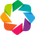

In [ ]:
import pandas as pd
import numpy as np
import holoviews as hv
import panel as pn

hv.extension("bokeh")
pn.extension()

In [2]:
nchannels = 3
stream_seconds = 10
buffer_length = 1000

# Buffer: Initialize with some random data
buffer = hv.streams.Buffer(
    data=pd.DataFrame(np.random.randn(10, nchannels).cumsum(axis=1),
                      columns=[chr(65 + i) for i in range(nchannels)]),
    length=buffer_length
)

# DynamicMap: Link the buffer to the visualization
def out(data):
    return hv.NdOverlay(
        {chr(65+i): hv.Curve(data, 'index', (chr(65+i), 'Amplitude')).opts(
            subcoordinate_y=True, xlabel='Sample')
         for i in range(nchannels)}
    )

dmap = hv.DynamicMap(out, streams=[buffer]).opts(
    legend_position='right', responsive=True, height=400,
    title='Minimal Example: Streaming Random Data',
)

# Periodic Callback: Generate and stream new data
def generate_data():
    index_start = buffer.data.index[-1] + 1 if not buffer.data.empty else 0
    new_data = pd.DataFrame(
        np.random.randn(10, nchannels).cumsum(axis=1),
        columns=[chr(65 + i) for i in range(nchannels)],
        index=np.arange(index_start, index_start + 10)
    )
    # Unlock: Use unlocked to ensure UI responsiveness
    with pn.io.unlocked():
        buffer.send(new_data)

# Run the stream for certain duration (timeout in ms)
periodic_cb = pn.state.add_periodic_callback(generate_data, period=100, timeout=stream_seconds*1000)

# Add a stream toggle button for the periodic callback
toggle_button = pn.widgets.Toggle(name='Toggle Stream', value=True, button_type='primary')
# Sync button and callback using `.link` with bidirectional=True and value='running'
toggle_button.link(periodic_cb, bidirectional=True, value='running')

pn.Row(toggle_button, pn.pane.HoloViews(dmap))

BokehModel(combine_events=True, render_bundle={'docs_json': {'f60e2f9c-34d7-49de-9252-6a7743bbb9ee': {'version…

# Penguin Crossfilter

https://panel.holoviz.org/gallery/penguin_crossfilter.html

In [10]:
import numpy as np
import pandas as pd
import panel as pn

import holoviews as hv
import hvplot.pandas # noqa

pn.extension(template='fast')

### Load data

In [ ]:

penguins = pd.read_csv('https://datasets.holoviz.org/penguins/v1/penguins.csv')
penguins = penguins[~penguins.sex.isnull()].reset_index().sort_values('species')

penguins.head()

,index,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
94,100,Adelie,Biscoe,35.0,17.9,192.0,3725.0,female,2009
95,101,Adelie,Biscoe,41.0,20.0,203.0,4725.0,male,2009
96,102,Adelie,Biscoe,37.7,16.0,183.0,3075.0,female,2009
97,103,Adelie,Biscoe,37.8,20.0,190.0,4250.0,male,2009


### Link selection

In [6]:
ls = hv.link_selections.instance()

def count(selected):
    return f"## {len(selected)}/{len(penguins)} penguins selected"

selected = pn.pane.Markdown(
    pn.bind(count, ls.selection_param(penguins)),
    align='center', width=400, margin=(0, 100, 0, 0)
)

header = pn.Row(
    pn.layout.HSpacer(), selected,
    sizing_mode='stretch_width'
).servable(area='header')

selected

BokehModel(combine_events=True, render_bundle={'docs_json': {'069acb03-282d-4516-9e13-ae505c3bd726': {'version…

### Plots

In [ ]:
colors = {
    'Adelie': '#1f77b4',
    'Gentoo': '#ff7f0e',
    'Chinstrap': '#2ca02c'
}

scatter = penguins.hvplot.points(
    'bill_length_mm', 'bill_depth_mm', c='species',
    cmap=colors, responsive=True, min_height=300
)

histogram = penguins.hvplot.hist(
    'body_mass_g', by='species', color=hv.dim('species').categorize(colors),
    legend=False, alpha=0.5, responsive=True, min_height=300
)

bars = penguins.hvplot.bar(
    'species', 'index', c='species', cmap=colors,
    responsive=True, min_height=300, ylabel=''
).aggregate(function=np.count_nonzero)

violin = penguins.hvplot.violin(
    'flipper_length_mm', by=['species', 'sex'], cmap='Category20',
    responsive=True, min_height=300, legend='bottom_right'
).opts(split='sex')

# All plots are linked with ls()
plots = pn.pane.HoloViews(
    ls(scatter.opts(show_legend=False) + bars + histogram + violin).opts(sizing_mode='stretch_both').cols(2)
).servable(title='Palmer Penguins')

plots

BokehModel(combine_events=True, render_bundle={'docs_json': {'32211985-829a-4f92-950d-0941ebde8a4c': {'version…